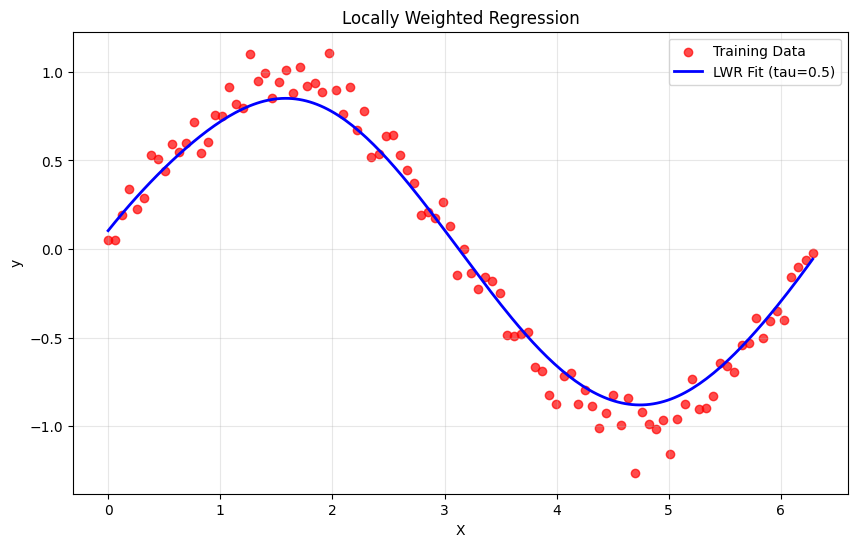

In [1]:
#lab6
import numpy as np
import matplotlib.pyplot as plt

def gaussian_kernel(x, xi, tau):
    return np.exp(-np.sum((x - xi)**2) / (2 * tau**2))

def lwr(x, X, y, tau):
    W = np.diag([gaussian_kernel(x, xi, tau) for xi in X])
    theta = np.linalg.inv(X.T @ W @ X) @ X.T @ W @ y
    return x @ theta

np.random.seed(42)

X = np.linspace(0, 2*np.pi, 100)
y = np.sin(X) + 0.1*np.random.randn(100)

Xb = np.c_[np.ones(X.shape), X]

xt = np.linspace(0, 2*np.pi, 200)
xtb = np.c_[np.ones(xt.shape), xt]

tau = 0.5
yp = np.array([lwr(xi, Xb, y, tau) for xi in xtb])

plt.figure(figsize=(10,6))
plt.scatter(X, y, c='red', label='Training Data', alpha=0.7)
plt.plot(xt, yp, c='blue', label=f'LWR Fit (tau={tau})', lw=2)
plt.xlabel('X'); plt.ylabel('y')
plt.title('Locally Weighted Regression')
plt.legend(); plt.grid(alpha=0.3)
plt.show()